<a href="https://colab.research.google.com/github/Tchalz/delete_now/blob/master/ASSIGNMENT_3%5BDIABETES%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##IMPORTING LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

##LOAD DATASET

In [3]:
df = pd.read_csv('/content/diabetes.csv')

##DISPLAY FIRST 5 ROWS

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


##DISPLAY COLUMN  HEADERS

In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

##DEFINE FEATURES AND TARGETS

In [6]:
x = df.drop('Outcome', axis=1)
y = df['Outcome']

##TRAIN TEST SPLIT

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

##FEATURE SCALING

In [8]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

##BUILD LOGISTIC REGRESSION MODEL

In [9]:
model = LogisticRegression(max_iter=1000)


##TRAIN THE MODEL

In [10]:
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

##MAKE PREDICTION

In [11]:
y_pred = model.predict(x_test)


In [12]:
y_prob = model.predict_proba(x_test)[:,1]

##CHECK ACCURACY

In [13]:
print('Accuracy:', accuracy_score(y_test, y_pred))


Accuracy: 0.7532467532467533


##CONFUSION MATRIX

[[79 20]
 [18 37]]


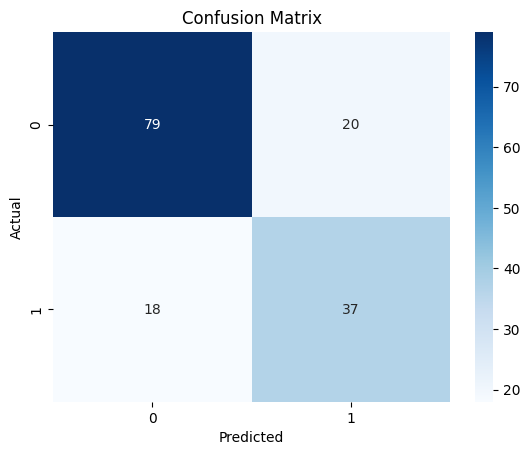

In [14]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##CLASSIFICATION REPORT

In [15]:


print('Classification Report:\n', classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



##SHOW PROBABILTIES PREDICTION

In [16]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Probability': y_prob})
print(results.head(20))

     Actual  Predicted  Probability
668       0          0     0.277364
324       0          0     0.185960
624       0          0     0.114658
690       0          0     0.171396
473       0          0     0.468438
204       0          0     0.439946
97        0          0     0.016192
336       0          1     0.659551
568       0          1     0.536164
148       0          1     0.770583
667       1          0     0.253939
212       0          1     0.891413
199       1          0     0.332872
265       0          0     0.312889
760       0          0     0.085349
356       1          0     0.386317
501       0          0     0.139407
457       0          0     0.076540
604       1          1     0.857810
213       1          1     0.555217
